# Глава 4: Создание GPT-подобной модели для генерации текста с нуля

In [1]:
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install matplotlib torch tiktoken

Note: you may need to restart the kernel to use updated packages.


In [3]:
from importlib.metadata import version

print("Версия matplotlib:", version("matplotlib"))
print("Версия torch:", version("torch"))
print("Версия tiktoken:", version("tiktoken"))

Версия matplotlib: 3.10.9
Версия torch: 2.11.0
Версия tiktoken: 0.12.0


- Внедрение архитектуры LLM, подобную GPT

<img src="https://camo.githubusercontent.com/b54d2f0c11a8979798a453d6a47b3cc58c8ec44c4a5983074a0c895416d3b4ce/68747470733a2f2f73656261737469616e72617363686b612e636f6d2f696d616765732f4c4c4d732d66726f6d2d736372617463682d696d616765732f636830345f636f6d707265737365642f30312e77656270" width="800px">

## 4.1. Программирование архитектуры LLM

- Ранее обсуждались такие модели, как GPT и Llama, которые генерируют слова последовательно и основаны на декодирующей части оригинальной архитектуры transformer
- Поэтому эти LLM часто называют "подобными декодеру" LLM
- По сравнению с обычными моделями глубокого обучения, LLM имеют больший размер, в основном из-за огромного количества параметров, а не из-за объема кода
- Мы увидим, что многие элементы повторяются в архитектуре LLM

<img src="https://camo.githubusercontent.com/1a8b7609d44460e0b494557ab8f1a9de60283f9f66eb14bf9fa71356758aa65a/68747470733a2f2f73656261737469616e72617363686b612e636f6d2f696d616765732f4c4c4d732d66726f6d2d736372617463682d696d616765732f636830345f636f6d707265737365642f30322e77656270" width="800px">

- Ранее мы использовали небольшие размеры встраивания для ввода и вывода токенов для простоты иллюстрации, чтобы они уместились на одной странице
- В этой главе мы рассмотрим встраивание и размеры модели, аналогичные небольшой модели GPT-2
- Мы специально разработаем архитектуру самой маленькой модели GPT-2 (124 миллиона параметров), как описано в работе Рэдфорда и др. [Языковые модели являются многозадачными без контроля Learners](https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf ) (обратите внимание, что в первоначальном отчете это было указано как 117 миллионов параметров, но позже это было исправлено в модели хранилище весов)
- В будущем будет показано, как загрузить предварительно подготовленные веса в нашу реализацию, которая будет совместима с моделями типоразмеров с 345, 762 и 1542 миллионами параметров.

- Подробные сведения о конфигурации модели GPT-2 со 124 миллионами параметров включают:

In [4]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,    # Размер словаря
    "context_length": 1024, # Длина контекста
    "emb_dim": 768,         # Размерность вложения
    "n_heads": 12,          # Количество целей внимания
    "n_layers": 12,         # Количество слоев
    "drop_rate": 0.1,       # Процент отсева
    "qkv_bias": False       # Смещение запроса-ключа-значения
}

- Мы используем короткие имена переменных, чтобы избежать использования длинных строк кода в дальнейшем
- `vocab_size` указывает на размер словаря в 50 257 слов, поддерживаемый токенизатором BPE.
- `context_length` представляет максимальное количество входных токенов модели, которое обеспечивается позиционными встраиваниями.
- `emb_dim` - это размер встраивания для входных токенов, преобразующий каждый входной токен в 768-мерный вектор.
- `n_heads` - это количество головок для управления вниманием в механизме управления несколькими головами.
- `n_layers` - это количество блоков-трансформаторов в модели, которые мы будем реализовывать в следующих разделах.
- `drop_rate` - это интенсивность механизма отсева, обсуждаемая в главе 3; 0,1 означает снижение 10% скрытых единиц во время обучения для уменьшения переобучения.
- `qkv_bias` определяет, должны ли "линейные" уровни в механизме многопоточного внимания включать вектор смещения при вычислении тензоров запроса (Q), ключа (K) и значения (V); мы отключим.

<img src="https://camo.githubusercontent.com/3d1152e718c0f7c8eaf876f03d500f089135acced7b2efe10d8a2292e24d3915/68747470733a2f2f73656261737469616e72617363686b612e636f6d2f696d616765732f4c4c4d732d66726f6d2d736372617463682d696d616765732f636830345f636f6d707265737365642f30332e77656270" width="800px">

In [5]:
import torch
import torch.nn as nn


class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        
        # Использование заполнителя для блока-трансформера
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        
        # Использование заполнителя для LayerNorm
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits


class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        # Простой заполнитель

    def forward(self, x):
        # Этот блок ничего не делает и просто возвращает свои входные данные
        return x


class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()
        # Приведенные здесь параметры предназначены только для имитации интерфейса LayerNorm

    def forward(self, x):
        # Этот слой ничего не делает и просто возвращает свои входные данные
        return x

 ---

### Описание кода выше

Это **упрощённая (заглушка) GPT-подобная модель**. Она имитирует архитектуру GPT, но без реальных вычислений — все блоки просто возвращают входные данные без изменений. Нужна для отладки, тестирования и понимания структуры.

### 1. Главный класс `DummyGPTModel`

```python
class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )
```

**Послойно:**

| Компонент | Что делает |
|-----------|------------|
| `tok_emb` | Таблица эмбеддингов токенов. Каждому ID токена сопоставляет вектор размером `emb_dim` |
| `pos_emb` | Таблица позиционных эмбеддингов. Каждой позиции в последовательности сопоставляет вектор |
| `drop_emb` | Dropout — случайно зануляет часть значений при обучении для борьбы с переобучением |
| `trf_blocks` | Цепочка из `n_layers` блоков-трансформеров (сейчас это заглушки) |
| `final_norm` | Финальная нормализация (заглушка) |
| `out_head` | Линейный слой, который превращает векторы размером `emb_dim` в логиты для каждого токена словаря |

### 2. Метод `forward` — прямой проход

```python
def forward(self, in_idx):
    batch_size, seq_len = in_idx.shape  # например (2, 10) — 2 текста по 10 токенов
    
    tok_embeds = self.tok_emb(in_idx)   # токены → векторы
    pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))  # позиции → векторы
    x = tok_embeds + pos_embeds          # складываем: "что" + "где"
    x = self.drop_emb(x)                 # дропаут - это когда во время обучения нейросеть случайно затыкает часть нейронов, чтобы она не читерила и не запоминала тупо наизусть
    x = self.trf_blocks(x)               # трансформерные блоки (пока ничего не делают)
    x = self.final_norm(x)               # нормализация (пока ничего не делает)
    logits = self.out_head(x)            # векторы → вероятности токенов
    return logits
```

**Ключевая идея:** токен получает смысл из двух источников:
- **токен-эмбеддинг** — что это за слово
- **позиционный эмбеддинг** — на каком месте стоит

Они складываются, и дальше идут через трансформер.

### 3. Заглушки `DummyTransformerBlock` и `DummyLayerNorm`

```python
class DummyTransformerBlock(nn.Module):
    def forward(self, x):
        return x  # просто возвращает вход, ничего не меняя

class DummyLayerNorm(nn.Module):
    def forward(self, x):
        return x  # просто возвращает вход, ничего не меняя
```

Они нужны чтобы:
- код запускался без ошибок
- соблюдалась правильная структура модели
- позже их можно заменить на настоящие блоки

### Простыми словами:

Модель получает на вход индексы токенов → превращает в векторы → добавляет информацию о позиции → прогоняет через пустые блоки (как по трубе) → на выходе выдаёт логиты (оценки для каждого возможного токена). Это скелет GPT, в который потом вставят настоящие "мозги".

---

<img src="https://camo.githubusercontent.com/16436bc692fd2313bd5bc4d1cf001c0af6ee0f534875014765805a2bf8e62931/68747470733a2f2f73656261737469616e72617363686b612e636f6d2f696d616765732f4c4c4d732d66726f6d2d736372617463682d696d616765732f636830345f636f6d707265737365642f30342e776562703f313233" width="800px">

In [6]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")

batch = []

txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)
print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


In [7]:
torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)

logits = model(batch)
print("Форма выходных данных:", logits.shape)
print(logits)

Форма выходных данных: torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6754, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


## 4.2. Нормализация активаций с помошью слоев

- Нормализация уровня, также известная как LayerNorm ([Ba et al., 2016](https://arxiv.org/abs/1607.06450)), центрирует активации уровня нейронной сети вокруг среднего значения, равного 0, и нормализует их дисперсию до 1
- Это стабилизирует обучение и обеспечивает более быструю конвергенцию(процесс сближения, схождения или компромиссов) к эффективным весам.
- Нормализация слоя применяется как до, так и после модуля multi-head attention в блоке transformer, который мы реализуем позже; она также применяется перед окончательным выходным слоем

 ---

**Дисперсия** — это насколько числа в наборе **разбросаны** относительно среднего. Простыми словами: мера бардака.

### Пример:

**Зарплаты в двух отделах:**

| Отдел | Зарплаты | Средняя | Дисперсия |
|-------|----------|---------|-----------|
| A | 50, 50, 50, 50, 50 | 50 | **0** (все одинаково) |
| B | 10, 30, 50, 70, 90 | 50 | **800** (полный разброс) |

Средняя одинаковая, а ситуация — разная. Дисперсия это улавливает.

### Как считается:

1. Берёшь среднее
2. Смотришь, насколько каждое число от него отклонилось
3. Возводишь отклонения в квадрат (чтобы минусы не гасили плюсы)
4. Усредняешь

```
Числа: 2, 4, 6
Среднее: 4
Отклонения: -2, 0, +2
Квадраты: 4, 0, 4
Дисперсия: (4 + 0 + 4) / 3 = 2.67
```

### Простой смысл:

- **Дисперсия = 0** → всё одинаковое, скучно
- **Дисперсия маленькая** → все кучкуются рядом
- **Дисперсия большая** → разброс, хаос, всё вразнобой


### Где пригождается:

- **В нейросетях**: следят, чтобы дисперсия активаций не улетала в ноль или в космос (проблема затухающих/взрывных градиентов)
- **В статистике**: понять, насколько данные однородные
- **В жизни**: риск, стабильность, предсказуемость

Короче, **дисперсия — это число, которое говорит: "насколько тут всё через жопу"**.

---

<img src="https://camo.githubusercontent.com/8c3f45afb0ca5d89210e931050538e3157575d0010af9739e37fc0f4a2fe12e3/68747470733a2f2f73656261737469616e72617363686b612e636f6d2f696d616765732f4c4c4d732d66726f6d2d736372617463682d696d616765732f636830345f636f6d707265737365642f30352e77656270" width="800px">

- Давайте посмотрим, как работает нормализация слоя, передавая небольшую входную выборку через простой слой нейронной сети:

In [8]:
torch.manual_seed(123)

# создает 2 обучающих примера с 5 измерениями (функциями) в каждом
batch_example = torch.randn(2, 5) 

layer = nn.Sequential(nn.Linear(5, 6), nn.ReLU())
out = layer(batch_example)
print(out)

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


 ---

### Код выше

Это **два слоя нейросети, собранные в один блок**:

### По-простому:

```python
layer = nn.Sequential(nn.Linear(5, 6), nn.ReLU())
```

1. Берёт вектор из 5 чисел
2. Пропускает через полносвязный слой — получает 6 чисел
3. Применяет ReLU — все минусы превращает в ноль

### Что внутри:

| Часть | Что делает | По-человечески |
|-------|------------|----------------|
| `nn.Linear(5, 6)` | Полносвязный слой: умножает вход на матрицу весов 5×6 и добавляет смещение | Превращает 5 чисел в 6 новых |
| `nn.ReLU()` | `max(0, x)` — всё что меньше нуля становится нулём | Отсекает весь негатив |
| `nn.Sequential(...)` | Объединяет слои в цепочку | Вход → Linear → ReLU → выход |

### Что происходит с данными:

```python
# Вход: 5 чисел
input = [1.0, -2.0, 3.0, -4.0, 5.0]

# После Linear: 6 чисел (могут быть и отрицательные)
# Например: [0.5, -1.2, 3.4, -0.8, 2.1, -0.3]

# После ReLU: минусы → 0
# Результат: [0.5, 0.0, 3.4, 0.0, 2.1, 0.0]
```


### Аналогия:

Как конвейер:
- **Linear** — рабочий, который делает из 5 деталей 6 новых
- **ReLU** — контролёр, который бракует все отрицательные результаты (в ноль)

Короче, **обычный кирпичик нейросети: вход расширили с 5 до 6 и обрезали всё отрицательное**.

---

- Давайте вычислим среднее значение и дисперсию для каждого из двух приведенных выше входных данных:

In [9]:
mean = out.mean(dim=-1, keepdim=True)
var = out.var(dim=-1, keepdim=True)

print("Среднее:\n", mean)
print("Дисперсия:\n", var)

Среднее:
 tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
Дисперсия:
 tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


- Нормализация применяется к каждому из двух входных данных (строк) независимо; при использовании dim=-1 расчет выполняется по последнему измерению (в данном случае, измерению объекта) вместо измерения строки

<img src="https://camo.githubusercontent.com/a3af536eea25eac1a0f032dd7efd605ae3a3bad09349d07fce3a3913829002ad/68747470733a2f2f73656261737469616e72617363686b612e636f6d2f696d616765732f4c4c4d732d66726f6d2d736372617463682d696d616765732f636830345f636f6d707265737365642f30362e77656270" width="800px">

- Вычитание среднего значения и деление на квадратный корень из дисперсии (стандартное отклонение) приводит к тому, что входные данные получают среднее значение 0 и дисперсию 1 по измерению столбца (признака):

In [10]:
out_norm = (out - mean) / torch.sqrt(var)
print("Нормализованные выходы слои:\n", out_norm)

mean = out_norm.mean(dim=-1, keepdim=True)
var = out_norm.var(dim=-1, keepdim=True)
print("Среднее:\n", mean)
print("Дисперсия:\n", var)

Нормализованные выходы слои:
 tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)
Среднее:
 tensor([[9.9341e-09],
        [0.0000e+00]], grad_fn=<MeanBackward1>)
Дисперсия:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


- Каждый входной сигнал центрируется на 0 и имеет единичную дисперсию, равную 1; для улучшения читаемости мы можем отключить научную нотацию PyTorch:

In [11]:
torch.set_printoptions(sci_mode=False)
print("Среднее:\n", mean)
print("Дисперсия:\n", var)

Среднее:
 tensor([[0.0000],
        [0.0000]], grad_fn=<MeanBackward1>)
Дисперсия:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


 ---

### Научная нотация PyTorch


`sci_mode=False` — это настройка отображения тензоров в PyTorch, которая **отключает экспоненциальную (научную) нотацию** при печати.

### Зачем нужно:

По умолчанию PyTorch выводит очень маленькие или очень большие числа в научном формате:

```python
tensor([1.0000e-05, 1.0000e+00, 5.0000e+03])
```

С `sci_mode=False` числа отображаются нормально, по-человечески:

```python
tensor([0.00001, 1.0000, 5000.0000])
```

### Как использовать:

```python
torch.set_printoptions(sci_mode=False)
```

Один раз в начале кода — и все тензоры печатаются без `e-05` и `e+03`.

### Когда полезно:

- Отладка: смотреть на веса, градиенты, выходы слоёв
- Сравнение близких к нулю значений
- Когда научная нотация бесит и хочется видеть обычные числа

---

- Выше мы нормализовали характеристики каждого входного сигнала
- Теперь, используя ту же идею, мы можем реализовать класс `LayerNorm`:

In [12]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

 ---

### Код выше

Это код слоя **LayerNorm** — «нормализация слоя». Штука, которая приводит данные внутри нейросети в порядок, чтобы сети было легче учиться. Разберем по-простому, что тут происходит.

В нейросети числа гуляют туда-сюда. Проходят через слои, умножаются на веса — и могут стать либо огромными, либо микроскопическими. Сеть от этого тупит.

**Решение:** перед тем, как передать данные дальше, давай их «причешем». Сделаем так, чтобы у всех чисел среднее было примерно 0, а разброс — примерно 1. Это как перевести оценки с пятибалльной шкалы на стобалльную, чтобы легче сравнивать.

### Разбор кода

```python
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))
```

При создании слоя мы передаём `emb_dim` — это размер вектора (сколько чисел в одном объекте). Всё, что в `__init__` — это подготовка.

**`self.eps = 1e-5`**  
Это крошечное число, типа `0.00001`. Нужно, чтобы случайно не поделить на ноль. Чистая страховка.

**`self.scale` (масштаб) и `self.shift` (сдвиг)**  
Нормализация — это штука жёсткая. Мы числа жёстко подогнали под «среднее 0, разброс 1». Но вдруг сети это не нравится? Вдруг лучше, чтобы разброс был 2, а среднее 5?  
Мы даём сети **обучаемые ручки**: `scale` (умножить результат) и `shift` (прибавить к результату). Изначально это единицы и нули, но сеть сама их подкрутит, если надо.

```python
def forward(self, x):
    mean = x.mean(dim=-1, keepdim=True)
    var = x.var(dim=-1, keepdim=True, unbiased=False)
    norm_x = (x - mean) / torch.sqrt(var + self.eps)
    return self.scale * norm_x + self.shift
```

Это сам рабочий проход. Пришёл `x` — батч данных.

1.  **Считаем среднее**
    `mean = x.mean(dim=-1, keepdim=True)`
    Берём все числа в последнем измерении (dim=-1), считаем среднее. `keepdim=True` — чтобы размерность не потерялась, иначе потом не вычтем.

2.  **Считаем дисперсию (разброс)**
    `var = x.var(dim=-1, keepdim=True, unbiased=False)`
    Насколько числа далеко от среднего. Флаг `unbiased=False` значит «дели на N» (по-простому), а не на N-1 (статистический замут), так принято.

3.  **Нормализуем**
    `norm_x = (x - mean) / torch.sqrt(var + self.eps)`
    Классическая формула:
    *   Вычли среднее, чтобы центр был в 0.
    *   Поделили на корень из дисперсии, чтобы разброс стал 1.
    *   Добавили `eps`, чтобы если дисперсия = 0 (все числа одинаковые), то на ноль не делить, а на очень маленькое число.

4.  **Даём свободу сети**
    `return self.scale * norm_x + self.shift`
    Умножаем на обучаемый `scale` и добавляем `shift`. Если сеть захочет, она оставит всё как есть (scale=1, shift=0), а если надо — растянет и сдвинет.

### Простая аналогия

Представь поток оценок в школе: 2, 5, 3, 4...

1.  **Среднее и дисперсия:** Мы видим, что в среднем это 3.5, а разброс — плюс-минус 1.5.
2.  **Нормализация:** Переводим в систему «насколько оценка выше среднего».
    *   2 → `(2-3.5) / 1.5` = -1.0
    *   5 → `(5-3.5) / 1.5` = +1.0
3.  **Scale/Shift:** Учитель говорит: «Не хочу видеть отрицательные числа. Умножайте на 10 и прибавляйте 50».
    *   -1.0 → 40 баллов
    *   +1.0 → 60 баллов

### Итог
LayerNorm берёт данные, приводит к среднему 0 и разбросу 1, а потом даёт сети два рычажка (`scale` и `shift`), чтобы она могла это дело подкрутить под себя. Это стабилизирует обучение. Код выше — каноничная реализация этого процесса.

---

**Масштаб и сдвиг**
- Обратите внимание, что в дополнение к выполнению нормализации путем вычитания среднего значения и деления на дисперсию, мы добавили два обучаемых параметра, параметр `scale` (масштаб) и параметр `shift` (сдвиг)
- Начальные значения `scale` (умножение на 1) и `shift` (добавление 0) не имеют никакого эффекта; однако `scale` и `shift` являются настраиваемыми параметрами, которые LLM автоматически настраивает во время обучения, если будет определено, что это улучшит производительность модели на ее собственном компьютере. учебная задача
- Это позволяет модели определить подходящее масштабирование и сдвиг, которые наилучшим образом соответствуют обрабатываемым данным
- Обратите внимание, что мы также добавляем меньшее значение (`eps`) перед вычислением квадратного корня из дисперсии; это делается для того, чтобы избежать ошибок при делении на ноль, если дисперсия равна 0

**Предвзятая дисперсия**
- В приведенном выше расчете дисперсии установка `unbiased=False` означает использование формулы $\frac{\sum_i (x_i - \bar{x})^2}{n}$ для вычисления дисперсии, где n - размер выборки (в данном случае количество объектов или столбцов); эта формула не включает поправку Бесселя (которая использует `n-1` в знаменателе), что дает предвзятую оценку дисперсии 
- Для LLM, где размерность вложения `n` очень велика, разница между использованием n и `n-1`
 незначительна
- Однако GPT-2 был обучен с учетом смещенной дисперсии на уровнях нормализации, поэтому мы также применили эту настройку из соображений совместимости с предварительно обученными весами, которые мы загрузим в последующих главах

- Давайте теперь попробуем `LayerNorm` на практике:

In [13]:
# Создаем слой нормализации для чисел в векторе из 6 элементов
# Пропустили через него данные — получили «причёсанный» результат, где у каждой строчки среднее ~0, разброс ~1.
ln = LayerNorm(emb_dim=6)
out_ln = ln(out)

In [14]:
mean = out_ln.mean(dim=-1, keepdim=True)
var = out_ln.var(dim=-1, unbiased=False, keepdim=True)

print("Среднее:\n", mean)
print("Дисперсия:\n", var)

Среднее:
 tensor([[ 0.0000],
        [-0.0000]], grad_fn=<MeanBackward1>)
Дисперсия:
 tensor([[0.9995],
        [0.9997]], grad_fn=<VarBackward0>)


- Дисперсия не равна в точности 1, потому что мы используем "eps`

<img src="https://camo.githubusercontent.com/cacad04245ca88b64c960d372b282933cc7d7cbc0dd044dcf790bc6a9274acbc/68747470733a2f2f73656261737469616e72617363686b612e636f6d2f696d616765732f4c4c4d732d66726f6d2d736372617463682d696d616765732f636830345f636f6d707265737365642f30372e77656270" width="800px">

## 4.3. Реализация сети с прямым распространением и активацией GELU

- Реализуем небольшой подмодуль нейронной сети, который используется как часть блока transformer в LLMs
- Начинаем с функции активации
- В глубоком обучении функции активации ReLU (Rectified Linear Unit - выпрямленной линейной единицы измерения) широко используются из-за их простоты и эффективности в различных архитектурах нейронных сетей
- В LLMs, помимо традиционного ReLU, используются различные другие типы функций активации; двумя примечательными примерами являются GELU (Gaussian Error Linear Unit - линейная единица измерения погрешности по Гауссу) и SwiGLU (Swish-Gated Linear Unit - линейная единица измерения с плавным стробированием)
- GELU и SwiGLU являются более сложными функциями плавной активации, включающими линейные единицы с гауссовым и сигмовидным стробированием, соответственно, что обеспечивает лучшую производительность для моделей глубокого обучения, в отличие от более простой кусочно-линейной функции ReLU

- GELU ([Хендрикс и Гимпель, 2016](https://arxiv.org/abs/1606.08415 )) может быть реализован несколькими способами; точная версия определяется как GELU(x)=x∈Φ(x), где Φ(x) - кумулятивная функция распределения стандартного гауссова распределения
- На практике обычно используется более дешевая с точки зрения вычислений аппроксимация: $\text{GELU}(x) \approx 0.5 \cdot x \cdot \left(1 + \tanh\left[\sqrt{\frac{2}{\pi}} \cdot \left(x + 0.044715 \cdot x^3\right)\right]\right)
$ (исходная модель GPT-2 также была обучена с использованием этого приближения)

In [15]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) * 
            (x + 0.044715 * torch.pow(x, 3))
        ))

 ---

### Код выше

Это гладкая версия ReLU. Если ReLU просто обрубает отрицательные значения до нуля (работает как "вкл/выкл"), то GELU делает это плавно, учитывая вероятность. Именно она используется в современных моделях вроде GPT и BERT.

### Разбор класса

```python
class GELU(nn.Module):
    def __init__(self):
        super().__init__()
```
Это просто объявление класса-наследника стандартного модуля PyTorch. В `__init__` ничего особого нет, так как у GELU нет обучаемых параметров.

### Математика внутри `forward`

Вся магия здесь:
```python
0.5 * x * (1 + torch.tanh(
    torch.sqrt(torch.tensor(2.0 / torch.pi)) * 
    (x + 0.044715 * torch.pow(x, 3))
))
```

Это **аппроксимация** точной формулы GELU, которая использует функцию ошибок (erf). Ее вывели, чтобы считать быстрее, а результат почти не отличается. Формула работает так:

1. **`torch.pow(x, 3)`** — возводит входное число `x` в куб.
2. **`x + 0.044715 * ...`** — это основная "магия" аппроксимации. Она немного искривляет входной сигнал, чтобы он лучше ложился внутрь `tanh`.
3. **`torch.sqrt(torch.tensor(2.0 / torch.pi))`** — константный коэффициент (~0.7979), который масштабирует сигнал для `tanh`.
4. **`torch.tanh(...)`** — гиперболический тангенс выдает значение строго от -1 до 1. Он играет роль "сглаженной ступеньки".
5. **`0.5 * x * (1 + tanh(...))`** — хитрый трюк:
   - Если `x` большое положительное, `tanh` тоже будет близок к 1. Выходит `0.5 * x * 2 ≈ x`. Сигнал почти не меняется.
   - Если `x` большое отрицательное, `tanh` будет близок к -1. Выходит `0.5 * x * 0 ≈ 0`. Сигнал гасится.
   - В промежутке около нуля происходит плавный переход.

### Как это работает визуально
Представь, что `x` — это поток машин.
- **ReLU** ставит жесткий шлагбаум: если машина едет вперед — пропускает как есть, если назад — полностью блокирует.
- **GELU** — это шлагбаум, который плавно приоткрывается: если машина явно едет вперед, путь свободен. Если явно назад — дорога перекрыта. А если машина колеблется около нуля (неуверенный сигнал), она получает "штраф" и проезжает лишь частично, в зависимости от того, насколько она была близка к движению вперед.

Эта плавность помогает нейросети лучше обучаться, потому что градиент течет через любые значения, даже отрицательные (хоть и сильно уменьшенный), и нет мертвых зон, как у ReLU.

---

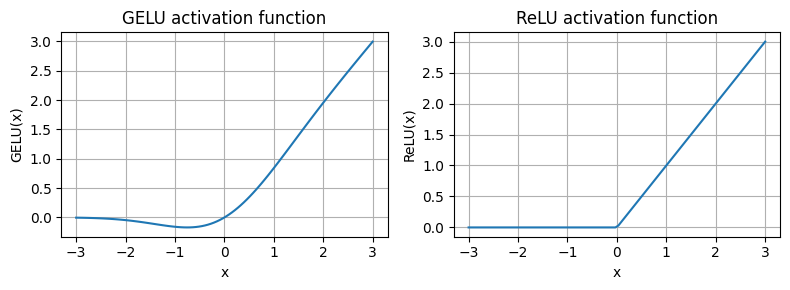

In [16]:
import matplotlib.pyplot as plt

gelu, relu = GELU(), nn.ReLU()

# Некоторые примеры данных
x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)

plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)

plt.tight_layout()
plt.show()

 ---

### Код выше

### 1. Подготовка к рисованию
```python
import matplotlib.pyplot as plt
```
Импортируем библиотеку для рисования графиков. Это как достать карандаши и лист бумаги.

### 2. Создаём обе функции активации
```python
gelu, relu = GELU(), nn.ReLU()
```
Здесь мы создаём два "чёрных ящика":
- `gelu` — наша функция, которую разбирали в прошлом вопросе (плавная, хитрая).
- `relu` — стандартный ReLU из PyTorch (`nn.ReLU()`), который просто отсекает всё отрицательное в ноль.
Теперь у нас есть два инструмента для преобразования чисел.

### 3. Готовим данные для графика
```python
x = torch.linspace(-3, 3, 100)
```
Создаём 100 точек, равномерно распределённых от -3 до 3: `[-3.0, -2.94, -2.88, ..., 0, ..., 2.88, 2.94, 3.0]`. Это будут значения по горизонтальной оси X.

### 4. Прогоняем данные через функции
```python
y_gelu, y_relu = gelu(x), relu(x)
```
Каждую точку из нашего списка `x` пропускаем через обе функции:
- `y_gelu` — что выдаст GELU для каждого из 100 чисел.
- `y_relu` — что выдаст ReLU для тех же чисел.
Теперь у нас есть тройка: `x` (входные значения), `y_gelu` (выходы GELU), `y_relu` (выходы ReLU).

### 5. Строим графики

```python
plt.figure(figsize=(8, 3))
```
Создаём холст для рисования размером 8×3 дюйма — достаточно широкий и невысокий, чтобы уместить два графика рядом.

```python
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
```
Этот цикл делает два прохода:
- Первый: `i=1`, `y=y_gelu`, `label="GELU"`
- Второй: `i=2`, `y=y_relu`, `label="ReLU"`

Для каждого прохода внутри цикла:
```python
    plt.subplot(1, 2, i)
```
Делим холст на 1 строку и 2 колонки. При `i=1` — левый график, при `i=2` — правый.

```python
    plt.plot(x, y)
```
Рисуем линию: по оси X откладываем наши 100 точек (от -3 до 3), по оси Y — то, что выдала функция для каждой из них (`y_gelu` или `y_relu`).

```python
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)
```
Добавляем подписи и красоту:
- Заголовок: "GELU activation function" или "ReLU activation function"
- Подпись горизонтальной оси: "x"
- Подпись вертикальной оси: "GELU(x)" или "ReLU(x)"
- Включаем сетку (`grid`), чтобы удобнее было смотреть на значения.

### 6. Показываем результат
```python
plt.tight_layout()
plt.show()
```
- `tight_layout()` автоматически подгоняет отступы, чтобы всё красиво влезло и не налезало друг на друга.
- `show()` выводит готовую картинку на экран.

### Что мы увидим на графиках?
- **Слева (GELU)**: плавная S-образная кривая в отрицательной части (немного изгибается, не уходит сразу в ноль) и почти прямая линия под углом в положительной.
- **Справа (ReLU)**: жёсткий угол в точке 0: слева от нуля — строго ноль, справа — прямая линия.

Этот код — простой и наглядный способ понять, почему GELU считается более "мягкой" и современной функцией активации по сравнению с классическим ReLU.

---

- Как мы можем видеть, ReLU - это кусочно-линейная функция, которая непосредственно выводит входные данные, если они положительны; в противном случае она выводит ноль
- GELU - это гладкая нелинейная функция, которая аппроксимирует ReLU, но с ненулевым градиентом для отрицательных значений (за исключением приблизительно -0,75).

- Далее, давайте внедрим небольшой модуль нейронной сети `FeedForward`, который мы позже будем использовать в трансформаторном блоке LLM:

In [17]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)

 ---

### Код выше

Этот код — реализация блока **FeedForward** (прямой связи), который используется внутри каждого слоя трансформера (например, в GPT).

### Что делает этот блок?
Его задача — взять информацию, которую слой внимания уже обработал, и "осмыслить" её глубже. Если слой внимания отвечает за поиск связей между словами, то FeedForward — за нелинейное преобразование каждого слова по отдельности. Это позволяет сети запоминать более сложные закономерности.

### Разбор класса

```python
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
```
Стандартно наследуемся от `nn.Module`. В конструктор передаётся словарь с конфигурацией `cfg`, где хранятся все настройки модели (как размеры, так и всякие флаги).

### Строим "слоёный пирог"
```python
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )
```
Ключевая часть — блок `nn.Sequential`, который последовательно применяет три операции одну за другой. Вся конструкция часто называется "расширяй-и-сжимай". Вот как это работает:

1. **Первый линейный слой: `nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"])`**
   - **Вход:** вектор размером `emb_dim` (пусть будет 768, как в базовом BERT).
   - **Выход:** вектор размером `4 * 768 = 3072`.
   - **Смысл:** Мы **расширяем** информацию в 4 раза. Представь, что у тебя есть краткое описание (embedding), и ты искусственно разворачиваешь его в более детальную, избыточную версию. Это даёт сети гораздо больше "комбинаторного пространства" для поиска нужных признаков.

2. **Функция активации: `GELU()`**
   - Это та самая плавная нелинейность, которую мы разбирали ранее. Она применяется к каждому из 3072 чисел.
   - **Зачем:** Без нелинейности два линейных слоя подряд схлопнулись бы в один линейный (потому что композиция линейных преобразований — это снова линейное преобразование). GELU добавляет изгиб, позволяя сети учить сложные, нелинейные зависимости. Она избирательно "выключает" или "приглушает" некоторые из 3072 признаков.

3. **Второй линейный слой: `nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"])`**
   - **Вход:** 3072-мерный вектор (после GELU).
   - **Выход:** обратно 768-мерный вектор.
   - **Смысл:** Мы **сжимаем** информацию обратно до исходного размера. Сеть как бы берёт все эти 3072 раздутых признака, перемешивает их и выделяет только самое важное, чтобы вернуть результат в ту же форму, которая была на входе. Это позволяет "воткнуть" блок в общую архитектуру (выход одного блока можно подать на вход другого).

### Прямой проход
```python
    def forward(self, x):
        return self.layers(x)
```
Входной тензор `x` (например, форма `[batch_size, num_tokens, emb_dim]`) просто пропускается через наш построенный `nn.Sequential`. Так как `nn.Linear` применяется к последней размерности, он обработает каждый токен (каждое слово) внутри батча независимо и параллельно.

### Простая аналогия
Представь, что ты редактор, и тебе принесли краткую заметку (`emb_dim = 768` слов смысла).

1. **Расширение (×4)**: Ты просишь автора искусственно раздуть заметку до 3072 слов — он добавляет кучу синонимов, оборотов, уточнений.
2. **GELU**: Ты читаешь этот раздутый текст и для каждой фразы решаешь: "Это важно — беру полностью, это сомнительно — беру с весом 0.5, а это бред — игнорирую".
3. **Сжатие (÷4)**: Ты переписываешь всё обратно в краткую заметку на 768 слов, но теперь она стала гораздо более насыщенной, умной и очищенной от шелухи.

Именно поэтому такая архитектура (расширение → нелинейность → сжатие) так хорошо работает в трансформерах.

---

In [18]:
print(GPT_CONFIG_124M["emb_dim"])

768


<img src="https://camo.githubusercontent.com/b5006caf8f949eeadb6f86194d0dbc68e1230c036497bf43b368b1aa5fd2c30a/68747470733a2f2f73656261737469616e72617363686b612e636f6d2f696d616765732f4c4c4d732d66726f6d2d736372617463682d696d616765732f636830345f636f6d707265737365642f30392e776562703f3132" width="800px">

In [19]:
ffn = FeedForward(GPT_CONFIG_124M)

# входная форма: [batch_size, num_token, emb_size]
x = torch.rand(2, 3, 768) 
out = ffn(x)
print(out.shape)

torch.Size([2, 3, 768])


<img src="https://camo.githubusercontent.com/f5635958e9ea3586b9b529697ab4da0b54962c6a715ab4b3b545cc2b6b350952/68747470733a2f2f73656261737469616e72617363686b612e636f6d2f696d616765732f4c4c4d732d66726f6d2d736372617463682d696d616765732f636830345f636f6d707265737365642f31302e77656270" width="800px">

<img src="https://camo.githubusercontent.com/48f50de2a64cd5d36488cb2699629d42094dfdd5abc5211a1611e7e795c7a951/68747470733a2f2f73656261737469616e72617363686b612e636f6d2f696d616765732f4c4c4d732d66726f6d2d736372617463682d696d616765732f636830345f636f6d707265737365642f31312e77656270" width="800px">

## 4.4. Добавление коротких соединений

- Далее поговорим о концепции коротких соединений, также называемых пропускными или остаточными соединениями
- Изначально короткие соединения были предложены в deep networks для компьютерного зрения (остаточные сети) для устранения проблем с исчезающим градиентом
- Короткие соединения создают альтернативный, более короткий путь для прохождения градиента по сети
- Это достигается путем добавления выходных данных одного слоя к выходным данным более позднего слоя, обычно пропуская один или несколько промежуточных слоев
- Давайте проиллюстрируем эту идею небольшим примером сети:

<img src="https://camo.githubusercontent.com/c8d3e676a7c4e7ece92848dd2064a6778672cefc1815b17fe9915a344d3961aa/68747470733a2f2f73656261737469616e72617363686b612e636f6d2f696d616765732f4c4c4d732d66726f6d2d736372617463682d696d616765732f636830345f636f6d707265737365642f31322e776562703f313233" width="800px">

- В коде это выглядит так:

In [20]:
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), GELU())
        ])

    def forward(self, x):
        for layer in self.layers:
            # Вычислить выходные данные текущего слоя
            layer_output = layer(x)
            # Проверка, можно ли применить ярлык
            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output
            else:
                x = layer_output
        return x


def print_gradients(model, x):
    # Прямой проход
    output = model(x)
    target = torch.tensor([[0.]])

    # Рассчитать потери, исходя из того, насколько близки цель
    # и результат
    loss = nn.MSELoss()
    loss = loss(output, target)
    
    # Обратный проход для вычисления градиентов
    loss.backward()

    for name, param in model.named_parameters():
        if 'weight' in name:
            # Вывод среднего абсолютного градиента весов
            print(f"{name} имеет среднее значение градиента {param.grad.abs().mean().item()}")

 ---

### Код выше

Этот код показывает две важные вещи: создание глубокой нейронной сети с "короткими соединениями" (shortcut connections) и проверку, не умирают ли в ней градиенты.

### Часть 1: Нейросеть с "короткими соединениями"

### Что это за сеть?
`ExampleDeepNeuralNetwork` — это учебный пример очень глубокой сети из 5 слоёв. Главная фишка здесь — **остаточные связи** (residual connections), которые помогают обучать глубокие сети без проблем.

### Конструктор
```python
def __init__(self, layer_sizes, use_shortcut):
    super().__init__()
    self.use_shortcut = use_shortcut
```
Сеть получает список размеров слоёв (например, `[10, 20, 20, 20, 20, 5]`) и флаг `use_shortcut` — включать ли "короткие пути". Это позволит нам сравнить, как сеть работает с ними и без них.

### Создание слоёв
```python
self.layers = nn.ModuleList([
    nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
    ... # и так 5 слоёв
])
```
- Создаётся 5 блоков подряд. Каждый блок — это линейный слой + активация GELU.
- `layer_sizes` определяет, сколько нейронов на каждом слое. Например, если `layer_sizes = [3, 5, 5, 5, 5, 2]`, то первый слой превращает 3 входа в 5 чисел, а последний — выдаёт 2 числа на выходе.

### Прямой проход — где магия!
```python
def forward(self, x):
    for layer in self.layers:
        layer_output = layer(x)
        if self.use_shortcut and x.shape == layer_output.shape:
            x = x + layer_output  # Вот он, "короткий путь"!
        else:
            x = layer_output
    return x
```

Проходим по всем слоям по очереди. Ключевой момент:

- **Обычный режим (`use_shortcut=False`):** `x = layer_output` — просто заменяем вход на выход слоя. Информация течёт строго вперёд.

- **Режим с shortcut (`use_shortcut=True`):** `x = x + layer_output` — мы **складываем** вход слоя с его выходом! Это и есть "короткий путь":
  - Вход `x` "перепрыгивает" через слой и сразу попадает на выход
  - Слой не должен заново выучивать то, что уже было хорошо — он учит лишь **разницу**, которую надо добавить к входу
  - Условие `x.shape == layer_output.shape` гарантирует, что мы не можем сложить тензоры разного размера. Поэтому shortcut сработает только если размер входа и выхода слоя совпадают (например, оба по 20 нейронов)

**Аналогия:** Представь, что ты делаешь ремонт в комнате.
- Без shortcut: Ты каждый раз перестраиваешь комнату с нуля, полностью заменяя старую.
- С shortcut: Ты берёшь то, что уже есть, и только немного улучшаешь (подкрашиваешь стены, меняешь лампу). Начинать не с нуля гораздо проще, и результат стабильнее.

Именно такая идея (ResNet) позволила обучать сети из сотен и тысяч слоёв без потери сигнала градиента.

### Часть 2: Проверка здоровья градиентов

Функция `print_gradients` — это как кардиограмма для нейросети. Она проверяет, не случилось ли "затухание градиента" (vanishing gradient) — главной болезни глубоких сетей без shortcut'ов.

### Шаг 1: Прямой проход и цель
```python
output = model(x)
target = torch.tensor([[0.]])
```
Пропускаем случайные данные через модель и говорим, что "правильный ответ" — 0. Хотим, чтобы сеть для всех входов выдавала `[[0.]]`.

### Шаг 2: Измеряем ошибку
```python
loss = nn.MSELoss()
loss = loss(output, target)
```
Сравниваем, что сеть реально выдала, с нашей целью 0. Чем разница больше, тем `loss` больше. Mean Squared Error — это просто средний квадрат отклонений.

### Шаг 3: Обратный проход (backpropagation)
```python
loss.backward()
```
Магия PyTorch: автоматически вычисляет, как каждый вес в сети повлиял на итоговую ошибку. Результат — градиент записывается в `param.grad` для каждого параметра.

### Шаг 4: Выводим средний градиент
```python
for name, param in model.named_parameters():
    if 'weight' in name:
        print(f"{name} имеет среднее значение градиента {param.grad.abs().mean().item()}")
```
Для каждого слоя смотрим на градиенты его весов:
- `param.grad` — насколько нужно изменить этот вес, чтобы уменьшить ошибку
- `.abs().mean()` — средняя абсолютная величина градиента (без учёта знака)

### Что мы ожидаем увидеть?

**С `use_shortcut=False` (без коротких путей):**
```
layers.0... среднее градиента: 0.0234
layers.1... среднее градиента: 0.0012  ← уже почти ноль!
layers.2... среднее градиента: 0.0003
layers.3... среднее градиента: 0.0001
layers.4... среднее градиента: 0.0000  ← градиент исчез
```
Градиенты катастрофически падают. Первый слой получает нормальный сигнал к обучению, а последний (ближайший к выходу) — почти ничего. Сеть перестаёт учиться в глубоких слоях.

**С `use_shortcut=True` (с короткими путями):**
```
layers.0... среднее градиента: 0.0211
layers.1... среднее градиента: 0.0198
layers.2... среднее градиента: 0.0203
layers.3... среднее градиента: 0.0221
layers.4... среднее градиента: 0.0195
```
Градиенты остаются здоровыми и стабильными на всех слоях! Информация об ошибке доходит до каждого слоя примерно в равной степени.

### Суть всего кода
Этот пример наглядно демонстрирует, почему короткие соединения произвели революцию в глубоком обучении. Без них градиент "выдыхается" уже через 5-10 слоёв. С ними можно строить сети из сотен слоёв, и каждый слой будет эффективно обучаться.

---

- **Без** коротких соединений:

In [21]:
layer_sizes = [3, 3, 3, 3, 3, 1]  

sample_input = torch.tensor([[1., 0., -1.]])

torch.manual_seed(123)
model_without_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=False
)
print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight имеет среднее значение градиента 0.00020173587836325169
layers.1.0.weight имеет среднее значение градиента 0.0001201116101583466
layers.2.0.weight имеет среднее значение градиента 0.0007152041653171182
layers.3.0.weight имеет среднее значение градиента 0.001398873864673078
layers.4.0.weight имеет среднее значение градиента 0.005049646366387606


- **С помощью** коротких соединений:

In [22]:
torch.manual_seed(123)
model_with_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=True
)
print_gradients(model_with_shortcut, sample_input)

layers.0.0.weight имеет среднее значение градиента 0.22169792652130127
layers.1.0.weight имеет среднее значение градиента 0.20694106817245483
layers.2.0.weight имеет среднее значение градиента 0.32896995544433594
layers.3.0.weight имеет среднее значение градиента 0.2665732502937317
layers.4.0.weight имеет среднее значение градиента 1.3258541822433472


- Как мы можем видеть из приведенных выше выходных данных, короткие соединения предотвращают исчезновение градиентов на ранних слоях (в направлении `layer.0`)
- Мы будем использовать эту концепцию быстрого соединения при реализации трансформаторного блока